In [1]:
from utils import load_batch
import matplotlib.pyplot as plt

In [2]:
X, Y, y = load_batch("data_batch_1")

/home/josef/Uni/P4/deep_learning/DD2424-assignments/assignment1/src/utils.py:20: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


In [3]:
X.shape
Y.shape

(10, 10000)

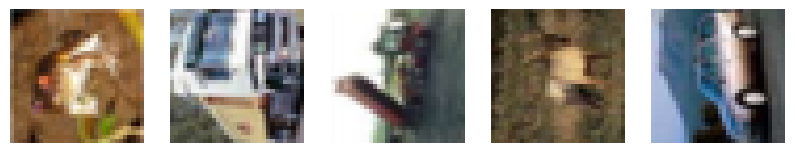

In [4]:
ni = 5
fig, axs = plt.subplots(1, 5, figsize=(10, 5))
for i in range(ni):
    X_im = X[:, i].reshape((32, 32, 3), order='F')
    axs[i].imshow(X_im)
    axs[i].axis('off')
plt.pause(0.1)

In [5]:
from scaler import Scaler

scaler = Scaler()
X_train = scaler.fit_transform(X)

In [6]:
from model import Model
model = Model(32*32*3, 10)
Y_pred = model.forward(X_train[:, :100])
Y_pred.shape

(10, 100)

In [7]:
Y_pred[:,0]

array([ 0.05121096,  0.62430223,  0.37207589,  0.0456761 , -0.43508798,
       -0.38045104, -0.52871895,  0.16379476, -0.18598619,  0.07368599])

In [8]:
from nodes import CrossEntropyLoss
loss_node = CrossEntropyLoss()

loss = loss_node.forward(Y_pred, Y[:, :100])
print(loss)

2.4165355967198696


In [9]:
grad = loss_node.backward()
print(grad.shape)

(10, 100)


In [10]:
model.backward(grad)
print(model.layers[0].grad_W[:3,0])

[-0.03240642 -0.02122973  0.01969531]


In [11]:
from torch_gradient_computations import ComputeGradsWithTorch
grads_torch = ComputeGradsWithTorch(X_train[:, :100], y[:100], model.layers[0].W, model.layers[0].b)
print(grads_torch['b'][:3,0])

[ 0.03556948 -0.03172503 -0.02823162]


In [12]:
print(model.layers[0].grad_b[:3])

[[ 0.03556948]
 [-0.03172503]
 [-0.02823162]]


In [13]:
from optimizer import Optimizer
model = Model(32*32*3, 10)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.01, reg=0.0)

In [14]:
X, Y, y = load_batch("data_batch_1")
X_train = X[:, :7000]
y_train = y[:7000]
X_val = X[:, 7000:]
y_val = y[7000:]
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

/home/josef/Uni/P4/deep_learning/DD2424-assignments/assignment1/src/utils.py:20: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


In [15]:
optimizer.train(X_train, y_train, X_val, y_val, num_epochs=40, batch_size=100, print_every=50)

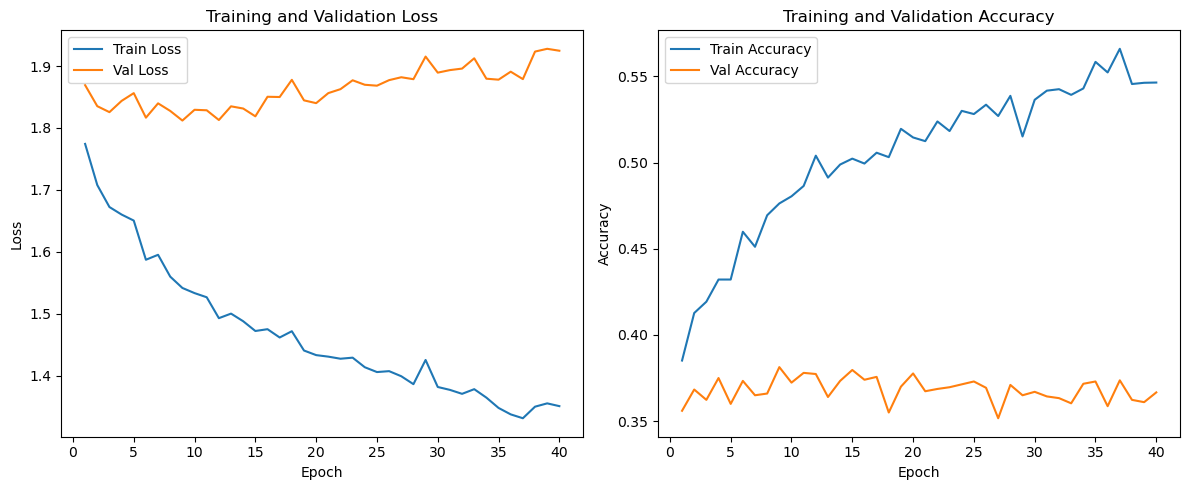

In [16]:
optimizer.plot_training_progress()

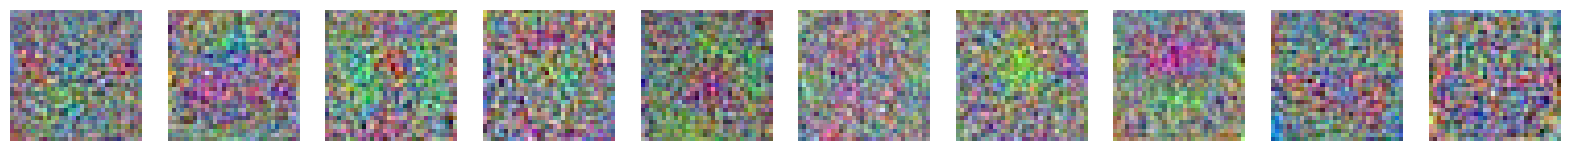

In [17]:
import numpy as np
W = model.layers[0].W
W_im = W.transpose().reshape((32,32,3,10), order='F')
W_im = np.transpose(W_im, (1, 0, 2, 3))
plt.figure(figsize=(20, 20))
for i in range(10):
    w_im = W_im[:, :, :, i]
    w_im = (w_im - w_im.min()) / (w_im.max() - w_im.min())
    plt.subplot(1, 10, i+1)
    plt.imshow(w_im)
    plt.axis('off')